# `mts_prev.ipynb` — quick MTS heatmap preview

Generate timeseries for one class from an experiment YAML, render heatmaps in the same format the pipeline produces (`build_mts_heatmap`), without writing anything to disk and without running PySPI.

Set `CONFIG`, `CLASS_NAME`, `N_INSTANCES` below and run.

In [249]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt

_repo_root = Path.cwd()
while _repo_root != _repo_root.parent and not (_repo_root / 'pyproject.toml').exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.mapping import DatasetMapping, ExperimentConfig
from src.run_experiments import build_mts_heatmap, generate_synthetic_from_spec

print(f'repo root: {_repo_root}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
repo root: /Users/wedi0306/Code/mts-spi-study-cluster


In [351]:
# --- knobs ---
CONFIG = 'configs/generate/embeddings/waves.yaml'
CLASS_NAME = 'wave-1d'   # set to None to list available classes
# CLASS_NAME = 'wave-1d-diamond'   # set to None to list available classes
# CLASS_NAME = 'wave-1d-pulse'   # set to None to list available classes
N_INSTANCES = 20                   # how many instances to render
M_FILTER = 10                   # e.g. 16 to pick a single M; None = first available
T_FILTER = 500                   # e.g. 1000 to pick a single T; None = first available

In [352]:
config = ExperimentConfig.from_file(_repo_root / CONFIG)
mapping = DatasetMapping(config)

all_specs = list(mapping.specs)
available_classes = sorted({s.mts_class for s in all_specs})

if CLASS_NAME is None:
    print('Available classes in config:')
    for c in available_classes:
        print(f'  - {c}')
    raise SystemExit

if CLASS_NAME not in available_classes:
    raise ValueError(f'class {CLASS_NAME!r} not in config. Available: {available_classes}')

specs = [s for s in all_specs if s.mts_class == CLASS_NAME]
if M_FILTER is not None:
    specs = [s for s in specs if s.M == M_FILTER]
if T_FILTER is not None:
    specs = [s for s in specs if s.T == T_FILTER]
if not specs:
    raise ValueError(f'No specs after M/T filter (M={M_FILTER}, T={T_FILTER}).')

# Pick the first (M, T) and take the first N_INSTANCES instances under it.
M0, T0 = specs[0].M, specs[0].T
specs = [s for s in specs if s.M == M0 and s.T == T0][:N_INSTANCES]
print(f'class={CLASS_NAME}  M={M0}  T={T0}  instances={[s.instance for s in specs]}')

class=wave-1d  M=10  T=500  instances=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


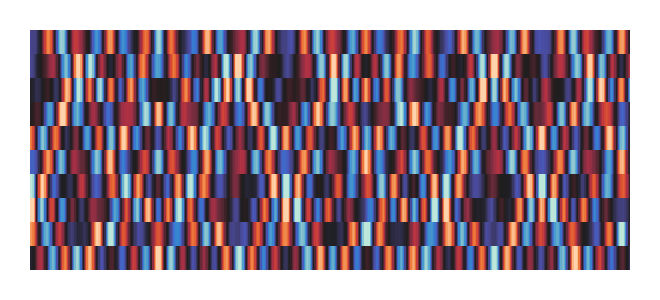

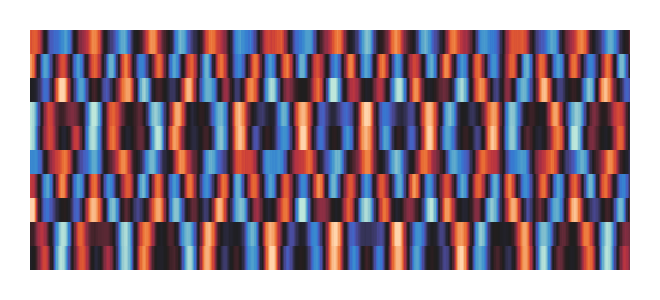

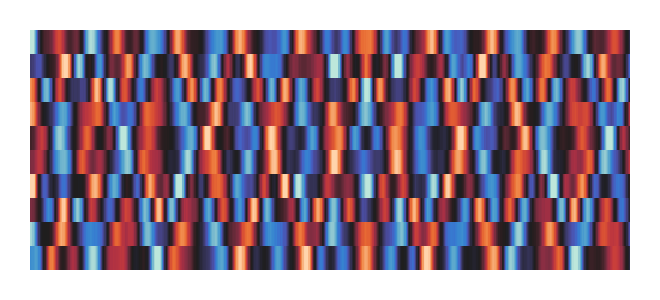

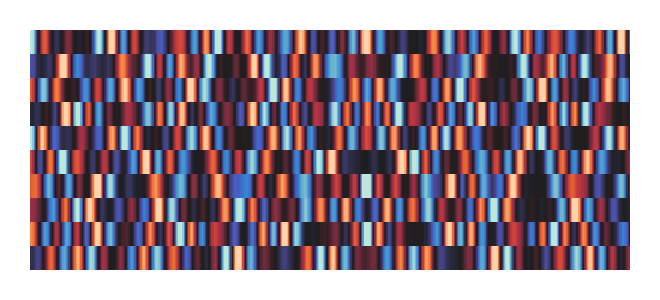

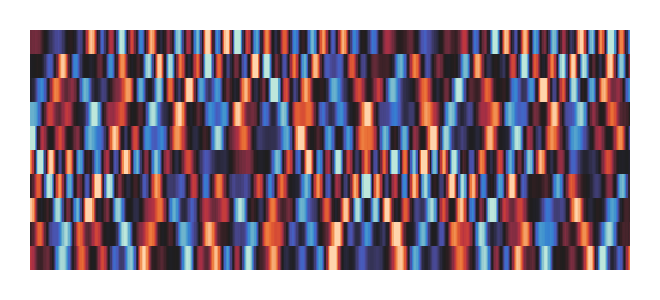

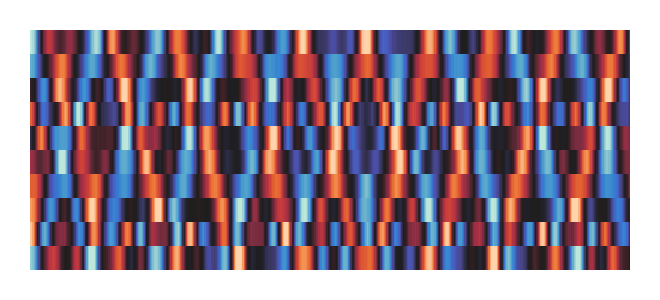

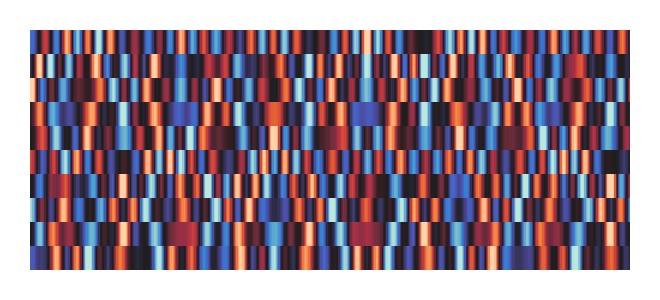

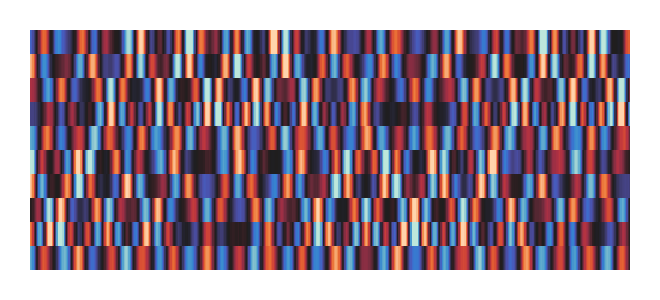

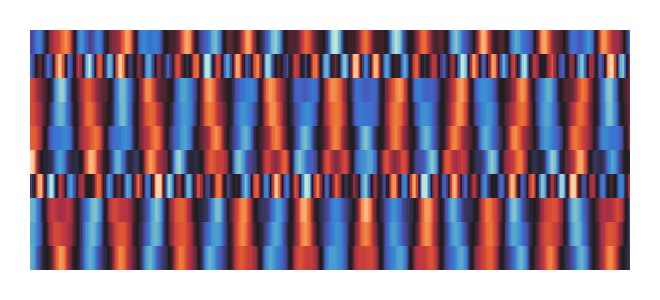

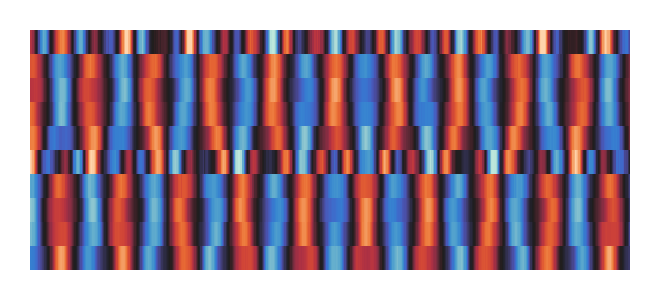

In [353]:
for spec in specs:
    data, _ = generate_synthetic_from_spec(spec)
    fig = build_mts_heatmap(data)
    plt.show()